# The LLC4320 grid

Reference documentation for the grid every field in this pipeline is
computed on.  Companions: [Gradients.md](../../docs/Gradients.md) (what
the differencing operators do with it) and
[Fields.md](../../docs/Fields.md) (per-channel reference).

Three things live here:

1. **Horizontally** — the Arakawa C grid, in ECCO / xmitgcm naming,
   with the tracer-gradient operation path drawn on it.
2. **Vertically** — the MITgcm column: `Z`, `Zl`, `Zu`, `Zp1`, `drF`,
   `drC`, and the sign convention that separates dbof from the model.
3. **The actual depths** — every level of the LLC_DEPTH store, read
   live from the grid (Section 3).  The schematic in Section 2 uses
   round illustrative numbers on purpose; Section 3 is the real thing.

Sections 1 and 2 need nothing but `matplotlib`.  Section 3 reads
`s3://dbof/LLC4320_RAW/DEPTH/grid.zarr`, so it needs NRP Nautilus
credentials — run it on a machine that has them.

Regenerate this notebook's skeleton with
`python notebooks/notebooks_field_validation/builders/build_grid_notebook.py`
(that OVERWRITES saved outputs — re-run afterwards).

## Section 1 — The horizontal grid (Arakawa C)

LLC4320 is an Arakawa C-grid ([MITgcm horizontal-grid
documentation](https://mitgcm.readthedocs.io/en/latest/algorithm/horiz-grid.html)):
tracers at cell **centres** `(j, i)`, `U` on the **west** faces
`(j, i_g)`, `V` on the **south** faces `(j_g, i)`, vorticity on the
**corners** `(j_g, i_g)`.

A finite difference moves a quantity by half a cell — differencing a
centre field lands on a face, differencing a face field lands on a
centre or a corner depending on direction.  That is the whole reason
the gradient routines interpolate at all, and the reason the ORDER of
squaring and interpolating matters (see Gradients.md).

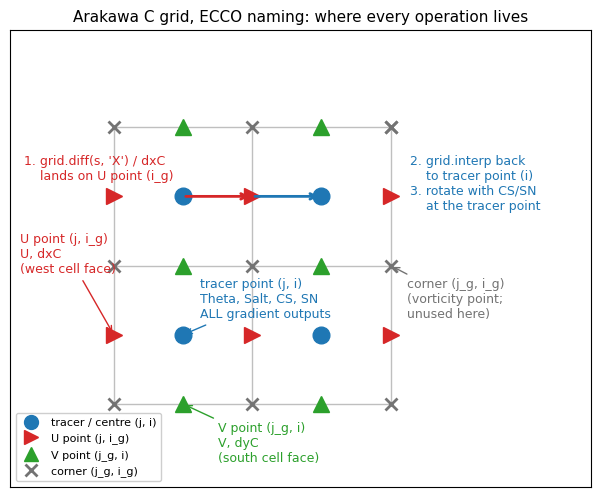

In [20]:
# Section 1: where every horizontal quantity lives.
import matplotlib.pyplot as plt

from dbof.plotting import schematics

schematics.draw_cgrid_schematic()
plt.show()

## Section 2 — The vertical grid (topology)

Cell centres `Z` (dim `k`) carry `Theta`, `Salt`, and `U`/`V` at the
same `k`; interfaces carry `W` (dim `k_l`).  The interface arrays
overlap: `Zp1` is all `nk+1` interfaces, `Zl` is the low-index
(shallower) one of each cell, `Zu` the high-index (deeper) one.

**The `l`/`u` suffixes are about INDEX POSITION, not depth**, and that
stays true under either sign convention — the single most common source
of off-by-one errors when reading MITgcm vertical output.

**Sign convention.** MITgcm/ECCO use a positive-UPWARD `Z`, so stored
values are negative below the surface.  dbof works in positive-DOWNWARD
depth (`vertical_helpers._get_depth_coord` flips the sign and warns).
The figure is drawn in dbof depth with the native value in parentheses.

The depths below are round illustrative numbers — the point of the
figure is the topology.  For the real levels see Section 3.

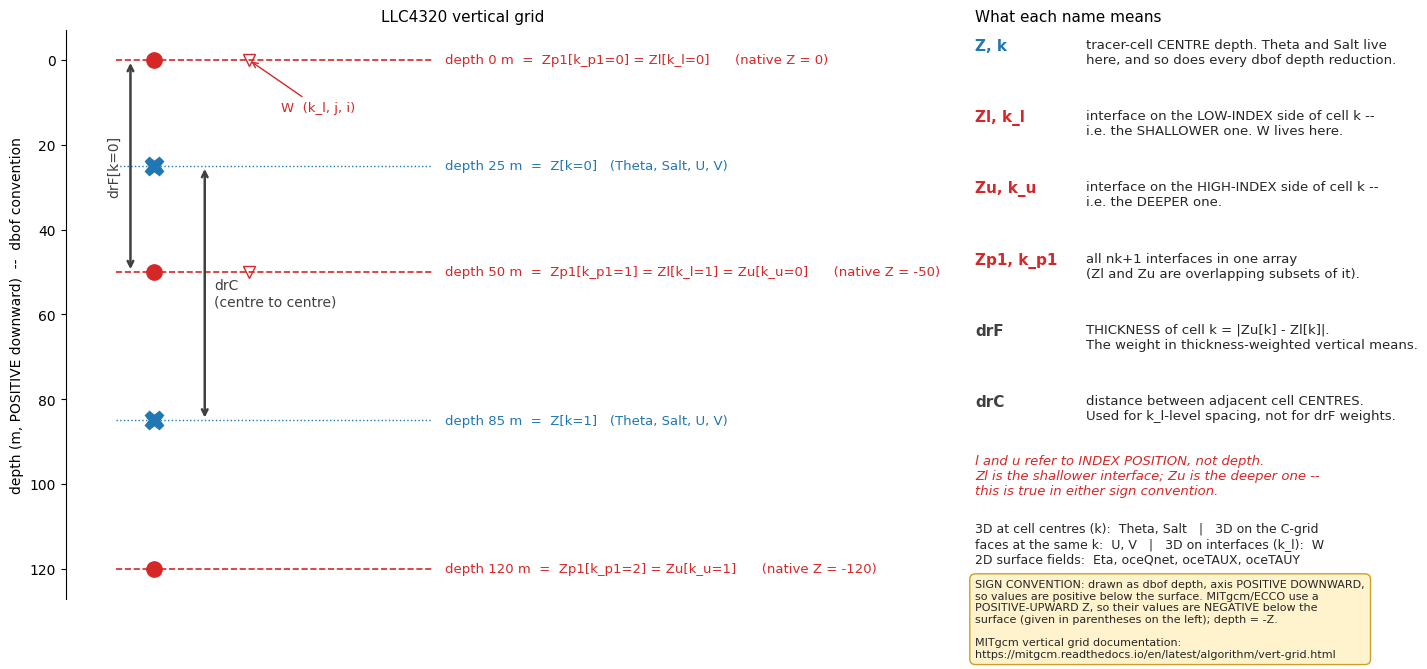

In [21]:
# Section 2: vertical topology and naming (illustrative depths).
schematics.draw_vertical_schematic()
plt.show()

## Section 3 — Every LLC4320 depth level, from the grid

Read live from `s3://dbof/LLC4320_RAW/DEPTH/grid.zarr` — the same
store the DEPTH pipeline uses (`grid_setup.set_up_grid("DEPTH", ...)`).
Only the 1-D vertical coordinates are pulled, so this is a small read;
the full grid is ~1.5 GB and is NOT loaded here.

**Note:** the raw LLC4320 grid has 90 vertical levels reaching ~7000 m;
this pipeline stores only the top 51 (to ~969 m).

Columns, all in metres and all POSITIVE DOWNWARD:

| column | meaning |
|---|---|
| `k` | tracer-level index |
| `Z_depth` | cell-centre depth (native `Z` = `-Z_depth`) |
| `Zl_depth` | shallower (low-index) interface of cell `k` |
| `Zu_depth` | deeper (high-index) interface of cell `k` |
| `drF` | cell thickness, `|Zu - Zl|` — the vertical-mean weight |
| `drC_to_next` | centre-to-centre distance from `k` to `k+1` |

`drC` is DERIVED here (`diff` of the centre depths): the grid store
carries `Z`, `Zl`, `Zu`, `Zp1` and `drF`, but not `drC`.

In [22]:
# Section 3a: pull the 1-D vertical coordinates from the grid store.
import numpy as np
import pandas as pd

from dbof.global_dataset_creation.data_sources import LLC_DEPTH_SOURCE
from dbof.llc4320_ingestion.get_raw_data import get_llc_depth_gridfile

_src = dict(LLC_DEPTH_SOURCE)
grid = get_llc_depth_gridfile(
    _src["s3_endpoint"], _src["bucket"],
    _src.get("grid_folder", _src["folder"]),
)   # lazy: nothing is read until we ask for the vertical vars


def as_depth(da):
    """1-D vertical coordinate as POSITIVE-DOWNWARD depth in metres.

    Mirrors ``vertical_helpers._get_depth_coord``: MITgcm stores these
    positive-upward (negative below the surface), dbof works in depth.
    Inputs: da (xr.DataArray, 1-D).
    Outputs: np.ndarray of depths, positive downward.
    Generated by LH and Claude
    """
    v = np.asarray(da.values, dtype=float)
    return -v if np.nanmean(v) < 0 else v


vert = {name: as_depth(grid[name])
        for name in ("Z", "Zl", "Zu", "Zp1", "drF") if name in grid}
print({k: v.shape for k, v in vert.items()})

/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(
/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(


LLC_DEPTH grid file loaded from s3://dbof/LLC4320_RAW/DEPTH/grid.zarr.
{'Z': (51,), 'Zl': (51,), 'Zu': (51,), 'Zp1': (52,), 'drF': (51,)}


In [23]:
# Section 3b: assemble the per-level table.
nk = vert["Z"].size
_drc = np.full(nk, np.nan)
_drc[:-1] = np.diff(vert["Z"])          # centre-to-centre, derived

levels = pd.DataFrame({
    "k": np.arange(nk),
    "Z_depth": vert["Z"],
    "Zl_depth": vert["Zl"][:nk] if "Zl" in vert else np.nan,
    "Zu_depth": vert["Zu"][:nk] if "Zu" in vert else np.nan,
    "drF": vert["drF"][:nk] if "drF" in vert else np.nan,
    "drC_to_next": _drc,
}).set_index("k")

print(f"{nk} levels; surface centre at {levels.Z_depth.iloc[0]:.3f} m, "
      f"deepest centre at {levels.Z_depth.iloc[-1]:.3f} m")
if "drF" in vert:
    print(f"column thickness (sum drF): {vert['drF'][:nk].sum():.2f} m")
with pd.option_context("display.max_rows", None,
                       "display.float_format", "{:.3f}".format):
    display(levels)

51 levels; surface centre at 0.500 m, deepest centre at 945.595 m
column thickness (sum drF): 968.62 m


,Z_depth,Zl_depth,Zu_depth,drF,drC_to_next
k,,,,,
0,0.500,-0.000,1.000,1.000,1.070
1,1.570,1.000,2.140,1.140,1.220
2,2.790,2.140,3.440,1.300,1.395
3,4.185,3.440,4.930,1.490,1.595
4,5.780,4.930,6.630,1.700,1.815
5,7.595,6.630,8.560,1.930,2.065
6,9.660,8.560,10.760,2.200,2.350
7,12.010,10.760,13.260,2.500,2.670
8,14.680,13.260,16.100,2.840,3.025


## Section 3.5 — Is the vertical spacing the same at every 2D point?

Half yes, half no, and the distinction matters for every vertical
average in the pipeline.

**The coordinate is 1-D.**  `Z`, `Zl`, `Zu`, `Zp1` and `drF` carry a
single `k` axis — Section 3a prints their shapes — so the NOMINAL
levels are identical over the whole globe.

**The effective thickness is 2-D.**  MITgcm shaves the deepest wet cell
of each column so the column bottom lands on the true bathymetry
instead of on the nearest grid interface (["partial
cells"](https://mitgcm.readthedocs.io/en/latest/algorithm/vert-grid.html)).
The open fraction is `hFacC(k, j, i)`: 1 for a fully wet cell, 0 below
the seafloor, and something in between in exactly one cell per column.
So the thickness to weight by is `hFacC * drF`, not `drF`, and two
things ARE per-column: how many levels are wet, and how thick the last
one is.

The identity that ties it to the map:

$$\sum_k \mathrm{hFacC}[k,j,i]\;\mathrm{drF}[k]\;=\;
\mathrm{Depth}[j,i]$$

— the 2-D bathymetry field *is* the vertical grid's 2-D content.

**Two practical traps, both handled below.**

*Truncation.*  The DEPTH store keeps only the top 51 levels, about
969 m (Section 3b prints the exact sum).  A column deeper than that
never reaches its seafloor within the store, so every one of its wet
cells is full and its bottom `hFacC` is exactly 1.0 — that is
truncation, NOT the absence of a partial cell.  Partial cells are
visible only on the shelf and slope, so every partial-cell diagnostic
here is restricted to columns that do reach the bottom.

*Cost.*  `hFacC` is 51 x 13 x 4320^2 (~49 GB) and the store is chunked
`(k=1, face=13, j=720, i=720)`, so striding saves no I/O — a strided
read still touches every chunk.  The 3-D work below runs on ONE
contiguous 720x720 native tile, chosen by a cheap 2-D scan so it
actually contains shelf.

In [24]:
# Section 3.5a: global Depth (2-D store) + the raw 3-D grid (hFacC).
import cmocean.cm as cmo
import xarray as xr

import dbof.io.filesystems as filesystems
import dbof.global_dataset_creation.zarr_grid_global as zarr_grid
from dbof.plotting import regions
from dbof.plotting.pipeline_grids import LAND_COLOR
# Same storage options the DEPTH loader uses (private, but replicating
# it here would let the two drift apart).
from dbof.llc4320_ingestion.get_raw_data import (
    _llc_depth_storage_options)

S3_ENDPOINT = _src["s3_endpoint"]

# --- the 2-D global grid store (already stitched to lat/lon) --------
fs_grid, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
reader2d = zarr_grid.GlobalGridZarrReader(
    bucket="dbof", folder="LLC4320_GRID_2D",
    dataset_name="llc4320_grid.zarr", fs=fs_grid,
)
_XC, _YC = reader2d.lon, reader2d.lat
_depth2d = reader2d["Depth"]
glon, glat, gdepth = regions.select_region(_depth2d, _XC, _YC,
                                           "global")
del _XC, _YC, _depth2d                            # ~900 MB each


def mask_seams(x, y, z, jump=20.0):
    """Blank cells that straddle a coordinate discontinuity.

    The stitched rect grid is an arrangement of LLC FACES, not a
    regular lat/lon grid: longitude wraps, and face boundaries jump.
    pcolormesh with 2-D coords draws one quad per cell, so a cell whose
    corners sit either side of a jump is painted as a band right across
    the map -- the stripes.  Blanking those few cells removes them.
    Inputs: x, y (2-D coords); z (2-D field); jump (degrees).
    Outputs: z with the straddling cells set to NaN.
    Generated by LH and Claude
    """
    m = np.zeros(z.shape, dtype=bool)
    for _a in (x, y):
        _d = np.abs(np.diff(_a, axis=1))
        m[:, :-1] |= _d > jump
        m[:, 1:] |= _d > jump
        _d = np.abs(np.diff(_a, axis=0))
        m[:-1, :] |= _d > jump
        m[1:, :] |= _d > jump
    return np.where(m, np.nan, z)


glon = ((glon + 180.0) % 360.0) - 180.0     # into [-180, 180)
gdepth = np.where(gdepth > 0, gdepth, np.nan)     # land -> NaN -> grey
_nseam = int(np.isnan(gdepth).sum())
gdepth = mask_seams(glon, glat, gdepth)
print(f"blanked {int(np.isnan(gdepth).sum()) - _nseam:,} seam cells "
      f"of {gdepth.size:,}")
print(f"global Depth, {regions.GLOBAL_DOWNSAMPLE}x downsampled: "
      f"{gdepth.shape}")

# --- the raw DEPTH grid store, for the 3-D hFacC -------------------
_bkt = _src["bucket"].strip("/")
_fld = _src.get("grid_folder", _src["folder"]).strip("/")
RAW_GRID_URL = f"s3://{_bkt}/{_fld}/grid.zarr"
graw = xr.open_zarr(
    RAW_GRID_URL, consolidated=False,
    storage_options=_llc_depth_storage_options(S3_ENDPOINT),
)
print(f"\n{RAW_GRID_URL}")
print(f"  Z    dims {graw.Z.dims}    shape {graw.Z.shape}")
print(f"  drF  dims {graw.drF.dims}  shape {graw.drF.shape}")
print(f"  hFacC dims {graw.hFacC.dims}  shape {graw.hFacC.shape}")
print("\n-> the vertical COORDINATE is 1-D (k only); the only 2-D "
      "vertical\n   information in the grid is hFacC.")

blanked 1,759 seam cells of 1,555,200
global Depth, 12x downsampled: (1080, 1440)

s3://dbof/LLC4320_RAW/DEPTH/grid.zarr
  Z    dims ('k',)    shape (51,)
  drF  dims ('k',)  shape (51,)
  hFacC dims ('k', 'face', 'j', 'i')  shape (51, 13, 4320, 4320)

-> the vertical COORDINATE is 1-D (k only); the only 2-D vertical
   information in the grid is hFacC.


In [25]:
# Section 3.5b: pick a tile that actually contains partial cells.
# Reads Depth for ONE face (2-D, ~75 MB retained) and ranks the
# 720x720 tiles by how many columns reach the seafloor within the
# stored levels.  Depth < Z_MAX is a proxy for that; the exact test
# (n_wet < nk) needs hFacC and is applied in 3.5c.
TILE_FACE = 1               # <-- change me to scan another face
TILE_N = 720                # one native chunk
TILE_J0 = TILE_I0 = None    # None = auto-pick the best tile below

Z_MAX = float(vert["drF"].sum())
print(f"stored column reaches {Z_MAX:.1f} m "
      f"({vert['Z'].size} levels) -- anything deeper is TRUNCATED\n")

_depf = graw.Depth.isel(face=TILE_FACE).load().values
_nt = _depf.shape[0] // TILE_N
_scan = []
for _jj in range(_nt):
    for _ii in range(_nt):
        _blk = _depf[_jj * TILE_N:(_jj + 1) * TILE_N,
                     _ii * TILE_N:(_ii + 1) * TILE_N]
        _oc = _blk > 0
        _scan.append((_jj * TILE_N, _ii * TILE_N, float(_oc.mean()),
                      float((_oc & (_blk < Z_MAX)).mean())))
_scan.sort(key=lambda r: -r[3])

print(f"face {TILE_FACE}: {_nt}x{_nt} tiles of {TILE_N}^2, ranked by "
      "the share of columns\nthat reach the seafloor within the "
      "stored levels\n")
print(f"{'j0':>6s} {'i0':>6s} {'ocean':>8s} {'reaches bottom':>15s}")
for _r in _scan[:8]:
    print(f"{_r[0]:6d} {_r[1]:6d} {100*_r[2]:7.1f}% {100*_r[3]:14.1f}%")

if TILE_J0 is None or TILE_I0 is None:
    TILE_J0, TILE_I0 = _scan[0][0], _scan[0][1]
    print(f"\nauto-picked tile j0={TILE_J0}, i0={TILE_I0} "
          f"({100*_scan[0][3]:.1f}% of columns reach the bottom)")
if _scan[0][3] < 0.01:
    print("\n!! No tile on this face has meaningful shelf -- panels "
          "(c)-(f) will be\n   nearly empty.  Try another TILE_FACE.")
del _depf

stored column reaches 968.6 m (51 levels) -- anything deeper is TRUNCATED

face 1: 6x6 tiles of 720^2, ranked by the share of columns
that reach the seafloor within the stored levels

    j0     i0    ocean  reaches bottom
  1440   2160    79.0%           12.6%
  2160   3600    68.5%            7.5%
  2160   2160    41.9%            7.5%
  3600    720    75.4%            6.8%
  3600   3600    31.5%            6.0%
  2880   2160    33.2%            5.1%
  2880   3600    77.5%            4.8%
  1440   2880    65.3%            4.8%

auto-picked tile j0=1440, i0=2160 (12.6% of columns reach the bottom)


In [26]:
# Section 3.5c: per-column diagnostics on that tile.
_jsl = slice(TILE_J0, TILE_J0 + TILE_N)
_isl = slice(TILE_I0, TILE_I0 + TILE_N)
_sel = dict(face=TILE_FACE, j=_jsl, i=_isl)

hfac = graw.hFacC.isel(**_sel).load()          # (k, j, i), one tile
dep_t = graw.Depth.isel(**_sel).load().values
lon_t = graw.XC.isel(**_sel).load().values
lat_t = graw.YC.isel(**_sel).load().values
drF = xr.DataArray(vert["drF"], dims="k")      # Section 3a, metres

n_wet = (hfac > 0).sum("k").values.astype(float)
n_part = ((hfac > 0) & (hfac < 1)).sum("k").values
hfac_bot = hfac.where(hfac > 0).min("k").values   # partials sit at
#                                                  the BOTTOM, so the
#                                                  minimum wet value
#                                                  IS the bottom cell
thick = (hfac * drF).sum("k").values

_ocean = n_wet > 0
_full = _ocean & (n_wet < hfac.sizes["k"])     # reaches the seafloor
_res = thick[_full] - dep_t[_full]

print(f"tile: face {TILE_FACE}, j {_jsl.start}:{_jsl.stop}, "
      f"i {_isl.start}:{_isl.stop}")
print(f"  lon {np.nanmin(lon_t):.2f} to {np.nanmax(lon_t):.2f}, "
      f"lat {np.nanmin(lat_t):.2f} to {np.nanmax(lat_t):.2f}")
print(f"  ocean columns: {_ocean.sum():,} of {_ocean.size:,}")
print(f"  reaching the seafloor within {hfac.sizes['k']} levels: "
      f"{_full.sum():,}")
print(f"\ncells with 0 < hFacC < 1 per column: max {n_part.max()} "
      "(expected <= 1 --\npartial cells only at the bottom)")
print(f"distinct wet-level counts: {len(np.unique(n_wet[_ocean]))}")
print(f"distinct bottom hFacC values (seafloor-reaching columns "
      f"only): {len(np.unique(np.round(hfac_bot[_full], 6))):,} "
      f"of {_full.sum():,}")
if _res.size:
    print(f"\nsum(hFacC*drF) - Depth over those columns:"
          f"\n  max |residual| {np.abs(_res).max():.3e} m, "
          f"median {np.median(np.abs(_res)):.3e} m")
    print("  -> the identity holds; the 2-D bathymetry IS the 2-D "
          "content of the\n     vertical grid.")
else:
    print("\n!! No column in this tile reaches the seafloor within "
          "the stored levels;\n   panels (c)-(f) will be empty.  "
          "Pick another tile in 3.5b.")

tile: face 1, j 1440:2160, i 2160:2880
  lon 7.01 to 21.99, lat -38.27 to -26.66
  ocean columns: 409,388 of 518,400
  reaching the seafloor within 51 levels: 64,661

cells with 0 < hFacC < 1 per column: max 1 (expected <= 1 --
partial cells only at the bottom)
distinct wet-level counts: 48
distinct bottom hFacC values (seafloor-reaching columns only): 39,546 of 64,661

sum(hFacC*drF) - Depth over those columns:
  max |residual| 2.956e-05 m, median 1.644e-06 m
  -> the identity holds; the 2-D bathymetry IS the 2-D content of the
     vertical grid.


/tmp/ipykernel_1584504/2667967237.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  _pm = _ax.pcolormesh(glon, glat, gdepth, cmap=cmo.deep,


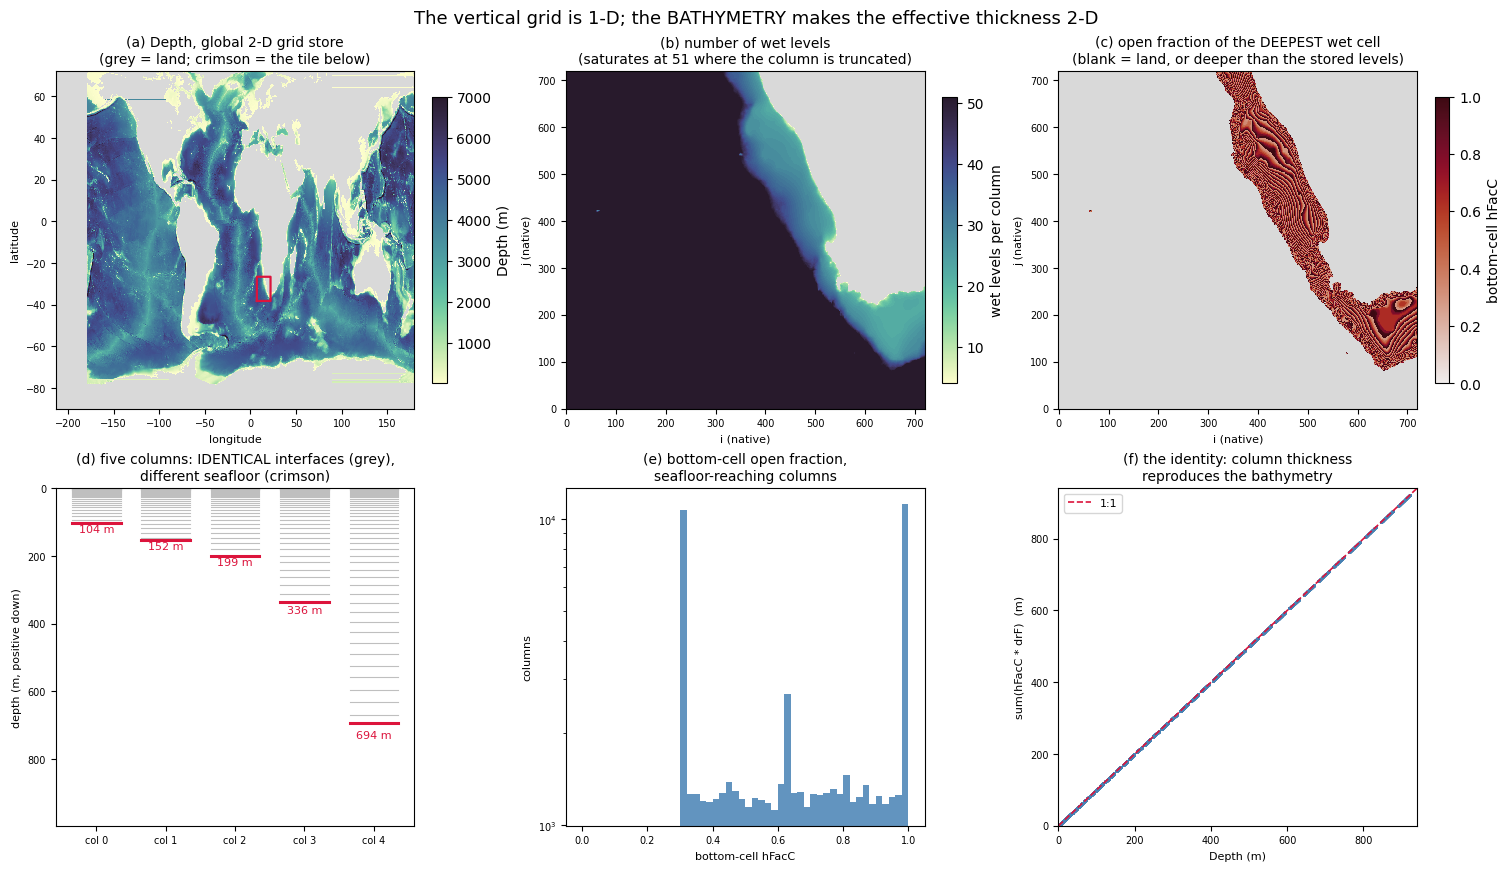

In [27]:
# Section 3.5d: the figure.
_fig = plt.figure(figsize=(15.0, 8.6), constrained_layout=True)
_gs = _fig.add_gridspec(2, 3)

# (a) global bathymetry, with the tile boxed.
_ax = _fig.add_subplot(_gs[0, 0])
_pm = _ax.pcolormesh(glon, glat, gdepth, cmap=cmo.deep,
                     shading="nearest")
_ax.set_facecolor(LAND_COLOR)
# The tile is a curved native patch, not a lat/lon rectangle --
# trace its actual perimeter.
_pl = np.concatenate([lon_t[0, :], lon_t[:, -1], lon_t[-1, ::-1],
                      lon_t[::-1, 0]])
_pa = np.concatenate([lat_t[0, :], lat_t[:, -1], lat_t[-1, ::-1],
                      lat_t[::-1, 0]])
if np.ptp(_pl) < 180.0:            # skip if it straddles the seam
    _ax.plot(_pl, _pa, color="crimson", lw=1.6)
_fig.colorbar(_pm, ax=_ax, shrink=0.85, label="Depth (m)")
_ax.set_title("(a) Depth, global 2-D grid store\n"
              "(grey = land; crimson = the tile below)",
              fontsize=10)
_ax.set_xlabel("longitude", fontsize=8)
_ax.set_ylabel("latitude", fontsize=8)
_ax.tick_params(labelsize=7)

# (b) how many levels are wet -- the same information, quantized.
_ax = _fig.add_subplot(_gs[0, 1])
_pm = _ax.pcolormesh(np.where(_ocean, n_wet, np.nan), cmap=cmo.deep,
                     shading="nearest")
_ax.set_facecolor(LAND_COLOR)
_fig.colorbar(_pm, ax=_ax, shrink=0.85, label="wet levels per column")
_ax.set_title(f"(b) number of wet levels\n(saturates at "
              f"{hfac.sizes['k']} where the column is truncated)",
              fontsize=10)
_ax.set_xlabel("i (native)", fontsize=8)
_ax.set_ylabel("j (native)", fontsize=8)
_ax.tick_params(labelsize=7)

# (c) the partial fraction of the deepest wet cell.
_ax = _fig.add_subplot(_gs[0, 2])
_pm = _ax.pcolormesh(np.where(_full, hfac_bot, np.nan),
                     cmap=cmo.amp, vmin=0, vmax=1, shading="nearest")
_ax.set_facecolor(LAND_COLOR)
_fig.colorbar(_pm, ax=_ax, shrink=0.85, label="bottom-cell hFacC")
_ax.set_title("(c) open fraction of the DEEPEST wet cell\n(blank = "
              "land, or deeper than the stored levels)", fontsize=10)
_ax.set_xlabel("i (native)", fontsize=8)
_ax.set_ylabel("j (native)", fontsize=8)
_ax.tick_params(labelsize=7)

# (d) a handful of columns side by side.
_ax = _fig.add_subplot(_gs[1, 0])
# Seafloor-reaching columns only -- a truncated column would draw its
# crimson bottom below the deepest stored interface.
_ord = np.argsort(dep_t[_full])
_deps = dep_t[_full][_ord]
_nw = n_wet[_full][_ord]
_pick = np.linspace(0.15, 0.95, 5)
_ifc = vert["Zp1"]
for _c, _q in enumerate(_pick):
    if _deps.size == 0:
        break
    _k = int(_q * (_deps.size - 1))
    _d, _n = float(_deps[_k]), int(_nw[_k])
    for _z in _ifc[:_n]:
        _ax.plot([_c - 0.35, _c + 0.35], [_z, _z], color="0.75",
                 lw=0.8, zorder=1)
    _ax.plot([_c - 0.35, _c + 0.35], [_d, _d], color="crimson",
             lw=2.2, zorder=3)
    _ax.text(_c, _d + 0.03 * _ifc[:_n + 1].max(), f"{_d:.0f} m",
             ha="center", va="top", fontsize=8, color="crimson")
_ax.set_ylim(0.0, float(_deps.max()) * 1.08 if _deps.size else 1.0)
_ax.invert_yaxis()
_ax.set_xticks(range(len(_pick)))
_ax.set_xticklabels([f"col {c}" for c in range(len(_pick))],
                    fontsize=8)
_ax.set_ylabel("depth (m, positive down)", fontsize=8)
_ax.set_title("(d) five columns: IDENTICAL interfaces (grey),\n"
              "different seafloor (crimson)", fontsize=10)
_ax.tick_params(labelsize=7)

# (e) are the bottom fractions really spread over (0, 1]?
_ax = _fig.add_subplot(_gs[1, 1])
_ax.hist(hfac_bot[_full], bins=50, range=(0, 1), color="steelblue",
         alpha=0.85, edgecolor="none")
_ax.set_yscale("log")
_ax.set_xlabel("bottom-cell hFacC", fontsize=8)
_ax.set_ylabel("columns", fontsize=8)
_ax.set_title("(e) bottom-cell open fraction,\nseafloor-reaching "
              "columns", fontsize=10)
_ax.tick_params(labelsize=7)

# (f) the identity, as a picture.
_ax = _fig.add_subplot(_gs[1, 2])
_ax.plot(dep_t[_full], thick[_full], ".", ms=1.5, alpha=0.3,
         color="steelblue")
_lim = [0, float(np.nanmax(dep_t[_full])) * 1.02] if _full.any() \
    else [0, 1]
_ax.plot(_lim, _lim, color="crimson", lw=1.2, ls="--", label="1:1")
_ax.set_xlim(_lim)
_ax.set_ylim(_lim)
_ax.set_xlabel("Depth (m)", fontsize=8)
_ax.set_ylabel("sum(hFacC * drF)  (m)", fontsize=8)
_ax.set_title("(f) the identity: column thickness\nreproduces the "
              "bathymetry", fontsize=10)
_ax.legend(fontsize=8)
_ax.tick_params(labelsize=7)

_fig.suptitle("The vertical grid is 1-D; the BATHYMETRY makes the "
              "effective thickness 2-D", fontsize=13)
plt.show()

## Section 3.6 — The 13 faces, and which way each one points

LLC4320 wraps the globe in 13 square faces: five cube facets plus an
Arctic cap (face 6).  Laid out in native index space they form the
familiar staircase — three faces up the left, three more beside them,
the cap, then two rows of three rotated faces.

**Orientation is the point.**  A unit vector along native `+i` maps to
`(CS, SN)` in (east, north), so geographic NORTH points `(-SN, CS)` in
native `(i, j)`.  The crimson arrow on each face is exactly that,
computed from the grid's own rotation coefficients — not drawn by hand.
Faces 0–5 and 7–12 differ by ~90 degrees across the cube seam, which is
why `CS`/`SN` exist at all, why `U`/`V` must be rotated before they
mean anything geographic, and why a constant-`j` line is NOT a line of
latitude.  Face 6 is the cap: its angle varies across it, so read its
single arrow as indicative only.

Cost: one full read of `Depth` (~1 GB) for the land masks — the store's
chunks span the face axis, so reading face-by-face would multiply the
traffic by 13 — plus one central chunk of `CS`/`SN`/`XC`/`YC`, which
covers every face at once for a few tens of MB.

 face  centre lon  centre lat  +i, deg E of east  N vs grad(YC)
    0        8.4       -75.8                0.0           5.0°  OK
    1        7.0       -26.7                0.0           0.0°  OK
    2        7.0        48.4                0.0           0.0°  OK
    3       95.6       -74.8                0.0           7.5°  OK
    4       97.0       -26.7                0.0           0.0°  OK
    5       97.0        48.4                0.0           0.0°  OK
    6        0.0        87.8                0.0          90.0°  <-- DISAGREES
    7     -172.5        48.4              -90.0           0.0°  OK
    8     -172.5       -26.7              -90.0           0.0°  OK
    9     -171.6       -75.8              -82.8           2.2°  OK
   10      -83.0        48.4              -90.0           0.0°  OK
   11      -83.0       -26.7              -90.0           0.0°  OK
   12      -84.4       -74.8                0.0          97.5°  <-- DISAGREES

0 deg = native +i points due EAST.  The ~9

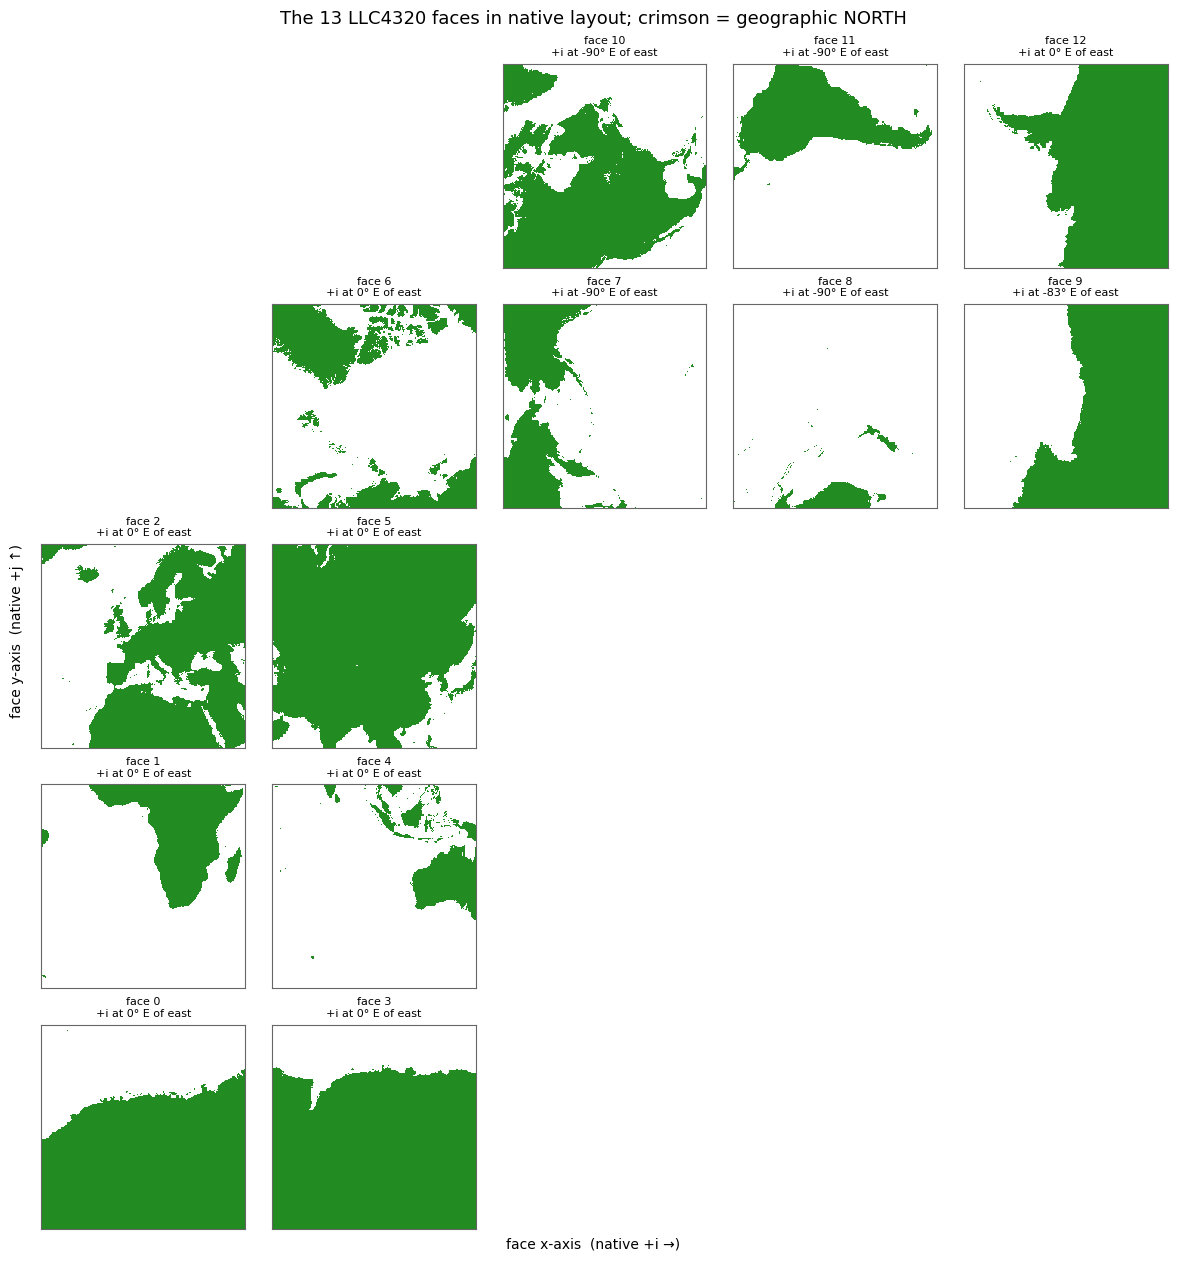

In [29]:
# Section 3.6: the 13 LLC faces, and which way each one points.
import matplotlib.colors as mcolors
# LLC layout: the 5 cube facets, as in the xmitgcm/ECCO tile figure.
# (col, row), row increasing UP.
LLC_LAYOUT = {0: (0, 0), 1: (0, 1), 2: (0, 2),
              3: (1, 0), 4: (1, 1), 5: (1, 2), 6: (1, 3),
              7: (2, 3), 8: (3, 3), 9: (4, 3),
              10: (2, 4), 11: (3, 4), 12: (4, 4)}
FACE_STRIDE = 16        # display only -- the read is chunk-bound
_CEN = slice(1800, 2520)   # one central chunk, covers ALL faces

# ONE read for all 13 faces: the store's chunks span the face axis, so
# reading face-by-face would multiply the traffic by 13.
_dep_all = graw.Depth.load().values
land = _dep_all[:, ::FACE_STRIDE, ::FACE_STRIDE] <= 0
del _dep_all

# Grid angle from the rotation coefficients themselves: a unit vector
# along native +i points (CS, SN) in (east, north), so geographic NORTH
# points (-SN, CS) in native (i, j).  Median over one central chunk;
# the cube facets are near-uniform, the Arctic cap (face 6) is not, so
# treat its arrow as indicative only.
_cs = graw.CS.isel(j=_CEN, i=_CEN).load().values
_sn = graw.SN.isel(j=_CEN, i=_CEN).load().values
_lon = graw.XC.isel(j=_CEN, i=_CEN).load().values
_lat = graw.YC.isel(j=_CEN, i=_CEN).load().values
ang = np.median(np.arctan2(_sn, _cs), axis=(1, 2))     # radians
face_lon = np.median(_lon, axis=(1, 2))
face_lat = np.median(_lat, axis=(1, 2))

# North in native (i, j) is (SN, CS) -- the INVERSE rotation, i.e. the
# transpose, not (-SN, CS).  Cross-check it against the grid geometry:
# latitude increases northward, so grad(YC) in native index space must
# point north as well.  The two must agree; if they do not, trust
# neither arrow on that face.
north_ij = np.stack([np.sin(ang), np.cos(ang)], axis=1)   # (i, j)
_dj, _di = np.gradient(_lat, axis=(1, 2))
_ang_cs = np.arctan2(np.cos(ang), np.sin(ang))            # from +i
_ang_yc = np.arctan2(np.median(_dj, axis=(1, 2)),
                     np.median(_di, axis=(1, 2)))
_disagree = np.abs(np.degrees(np.angle(
    np.exp(1j * (_ang_cs - _ang_yc)))))

print(f"{'face':>5s} {'centre lon':>11s} {'centre lat':>11s} "
      f"{'+i, deg E of east':>18s} {'N vs grad(YC)':>14s}")
for _f in range(land.shape[0]):
    _flag = "  OK" if _disagree[_f] < 15.0 else "  <-- DISAGREES"
    print(f"{_f:5d} {face_lon[_f]:10.1f}  {face_lat[_f]:10.1f}  "
          f"{np.degrees(ang[_f]):17.1f} {_disagree[_f]:13.1f}"
          f"°{_flag}")
print("\n0 deg = native +i points due EAST.  The ~90 deg jump between "
      "faces 0-5\nand 7-12 is the cube seam -- it is exactly why CS/SN "
      "exist, and why a\nconstant-j line is not a line of latitude.")
print("\nThe last column compares the CS/SN north against grad(YC), "
      "which must also\npoint north.  Anything but a small angle "
      "means the single-arrow summary\ndoes not hold on that face "
      "(expected for the Arctic cap).")

_nc = max(c for c, _ in LLC_LAYOUT.values()) + 1
_nr = max(r for _, r in LLC_LAYOUT.values()) + 1
_fig, _axes = plt.subplots(_nr, _nc, figsize=(2.35 * _nc, 2.5 * _nr),
                           layout="constrained")
for _ax in _axes.ravel():
    _ax.set_visible(False)
for _f, (_c, _r) in LLC_LAYOUT.items():
    _ax = _axes[_nr - 1 - _r, _c]          # row 0 of the array is TOP
    _ax.set_visible(True)
    _ax.imshow(np.where(land[_f], 1.0, np.nan), origin="lower",
               cmap=mcolors.ListedColormap(["forestgreen"]),
               vmin=0, vmax=1, interpolation="nearest")
    _n = land[_f].shape[0]
    _dx, _dy = north_ij[_f]
    _ax.set_title(f"face {_f}\n+i at {np.degrees(ang[_f]):.0f}"
                  "\u00b0 E of east", fontsize=8)
    _ax.set_xticks([])
    _ax.set_yticks([])
    for _s in _ax.spines.values():
        _s.set_edgecolor("0.4")
_fig.supxlabel("face x-axis  (native +i \u2192)", fontsize=10)
_fig.supylabel("face y-axis  (native +j \u2191)", fontsize=10)
_fig.suptitle("The 13 LLC4320 faces in native layout; crimson = "
              "geographic NORTH", fontsize=13)
plt.show()

## Section 4 — Write the documentation artifacts

`docs/` is plain markdown (Sphinx + MyST, no notebook renderer), so the
docs page gets PNGs plus a generated table rather than this notebook.
This cell writes:

- `docs/images/grid_cgrid_schematic.png`
- `docs/images/grid_vertical_schematic.png`
- `docs/images/sparkle_cancellation.png`
- the depth table, into `docs/Grid.md` between its
  `<!-- BEGIN depth-levels -->` / `<!-- END depth-levels -->` markers

The PNGs alone can be regenerated without this notebook (and without
credentials) by running
`python -m dbof.plotting.schematics --outdir docs/images`.

In [30]:
# Section 4: refresh docs/images/*.png and the docs/Grid.md table.
from pathlib import Path

BEGIN = "<!-- BEGIN depth-levels (generated by Grid.ipynb) -->"
END = "<!-- END depth-levels -->"


def repo_root(start=None):
    """Walk up from *start* to the directory holding pyproject.toml.

    Inputs: start (Path or None; defaults to the working directory).
    Outputs: Path of the repo root.
    Generated by LH and Claude
    """
    here = Path(start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists():
            return cand
    raise FileNotFoundError("no pyproject.toml above " + str(here))


def md_table(df, floatfmt="{:.3f}"):
    """Render a DataFrame as a GitHub/MyST markdown table.

    Hand-rolled so the docs build needs no ``tabulate`` dependency.
    Inputs: df (pd.DataFrame, index is written as its own column);
    floatfmt (format string for float cells).
    Outputs: str.
    Generated by LH and Claude
    """
    cols = [df.index.name or "index", *df.columns]
    out = ["| " + " | ".join(cols) + " |",
           "|" + "|".join(["---"] * len(cols)) + "|"]
    for idx, row in df.iterrows():
        vals = [str(idx)]
        for v in row:
            vals.append("" if pd.isna(v) else (
                floatfmt.format(v) if isinstance(v, float) else str(v)))
        out.append("| " + " | ".join(vals) + " |")
    return "\n".join(out)


def inject(path, body, begin=BEGIN, end=END):
    """Replace the text between two markers in a file, in place.

    Inputs: path (Path); body (str to place between the markers);
    begin/end (marker lines, which are preserved).
    Outputs: Path written.
    Generated by LH and Claude
    """
    text = Path(path).read_text()
    i, j = text.find(begin), text.find(end)
    if i < 0 or j < 0:
        raise ValueError(f"markers not found in {path}")
    new = text[:i] + begin + "\n\n" + body + "\n\n" + text[j:]
    Path(path).write_text(new)
    return Path(path)


root = repo_root()
for _p in schematics.save_all(root / "docs" / "images"):
    print(f"wrote {_p.relative_to(root)}")

# The PNGs need no data; the table only exists if Section 3 ran.
if "levels" in dir():
    _caption = (f"{nk} levels, read from "
                f"`{_src['bucket'].rstrip('/')}/"
                f"{_src.get('grid_folder', _src['folder'])}"
                "/grid.zarr`.  All values in metres, POSITIVE "
                "DOWNWARD (native MITgcm `Z` is the negative of "
                "`Z_depth`).  `drC_to_next` is derived from the "
                "centre depths.")
    _doc = inject(root / "docs" / "Grid.md",
                  _caption + "\n\n" + md_table(levels))
    print(f"wrote {_doc.relative_to(root)}")
else:
    print("Section 3 has not run -- docs/Grid.md table left as is.")

wrote docs/images/grid_cgrid_schematic.png
wrote docs/images/grid_vertical_schematic.png
wrote docs/images/sparkle_cancellation.png
wrote docs/Grid.md


## Where to go next

- **What the operators do with this grid** —
  [docs/Gradients.md](../../docs/Gradients.md), including the sparkle
  schematic (why the order of squaring and interpolating matters).
- **The A/B evidence for the square-first fix** —
  [field_validation_sparkle.ipynb](field_validation_sparkle.ipynb).
- **Per-channel definitions** —
  [docs/Fields.md](../../docs/Fields.md).
- **Vertical reductions** (`_sfc`, `_z25m`, `_mld`, `_mld_mean`) —
  `dbof.preprocessing.vertical_helpers`, whose depth handling is the
  convention drawn in Section 2.